# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Muhammad Rifqy Azhar Widiyatmoko
- Email: azharrifqy@gmail.com
- Id Dicoding: rifqy_azhar

## Business Understanding

**Jaya Jaya Institut** merupakan salah satu institusi pendidikan perguruan tinggi yang telah berdiri sejak tahun 2000 dan telah mencetak banyak lulusan dengan reputasi yang sangat baik. Akan tetapi, terdapat cukup banyak juga mahasiswa yang tidak menyelesaikan pendidikannya alias melakukan **dropout**.

Tingginya angka dropout ini menjadi salah satu masalah besar bagi sebuah institusi pendidikan. Oleh karena itu, Jaya Jaya Institut ingin dapat **mendeteksi secepat mungkin mahasiswa yang berpotensi melakukan dropout**, sehingga mahasiswa tersebut dapat diberikan bimbingan khusus sebelum benar-benar keluar dari perkuliahan.

### Permasalahan Bisnis

1. Seberapa besar tingkat dropout mahasiswa di Jaya Jaya Institut, dan faktor apa saja yang paling memengaruhinya?
2. Bagaimana cara membangun sebuah model machine learning yang dapat memprediksi status akhir mahasiswa Dropout atau Graduate berdasarkan data pribadi, finansial, dan akademiknya?
3. Rekomendasi *action items* apa yang bisa diambil oleh pihak manajemen Jaya Jaya Institut untuk menekan angka dropout?

### Cakupan Proyek

1. Data Understanding — memahami struktur data, mengecek kualitas data (missing value, duplikat), serta melakukan eksplorasi (EDA) untuk menemukan pola yang berkaitan dengan status mahasiswa.
2. Data Preparation — menyiapkan data (encoding target, train-test split, feature scaling) agar siap digunakan oleh model machine learning.
3. Modeling — melatih model klasifikasi (Random Forest) untuk memprediksi status mahasiswa.
4. Evaluation — mengevaluasi performa model menggunakan classification report, confusion matrix, dan feature importance.
5. Deployment — model yang telah dilatih diimplementasikan dalam bentuk *prototype* aplikasi berbasis **Streamlit** dan dihubungkan dengan **Streamlit Community Cloud**, serta dilengkapi dengan **business dashboard** (Looker Studio) untuk memonitor performa mahasiswa.

### Persiapan

- Sumber data: [Students' Performance Dataset](https://github.com/dicodingacademy/dicoding_dataset/blob/main/students_performance/README.md)
- Environment: Python 3.11.9, dijalankan di Jupyter Notebook / VS Code

## Persiapan

### Menyiapkan library yang dibutuhkan

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

Library yang digunakan pada proyek ini:
- pandas — membaca dan mengolah data tabular
- matplotlib & seaborn — membuat visualisasi data
- scikit-learn (LabelEncoder, train_test_split, StandardScaler, RandomForestClassifier, metrics) — proses preprocessing, pemodelan, dan evaluasi
- joblib — menyimpan model dan scaler agar bisa dipakai kembali pada prototype Streamlit

### Menyiapkan data yang akan diguankan

In [20]:
df = pd.read_csv('data/data.csv', sep=';')
print('Ukuran Dataset:', df.shape)
df.head()

Ukuran Dataset: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Dataset berhasil dimuat dengan ukuran **4.424 baris dan 37 kolom**. File menggunakan separator titik koma (;) karena berasal dari format CSV Eropa. Kolom Status merupakan target/label yang ingin diprediksi, berisi tiga kategori: Dropout, Enrolled, dan Graduate. Seluruh kolom fitur lainnya sudah berbentuk numerik (hasil encoding dari dataset sumber).

## Data Understanding

Pada tahap ini dilakukan pengecekan struktur data, kualitas data (missing value & duplikat), statistik deskriptif, serta eksplorasi visual (EDA) untuk memahami pola yang berkaitan dengan status mahasiswa.

In [21]:
print('Info Dataset:')
print(df.info())

print('\nMissing Values:')
print(df.isna().sum())

print('\nDuplicated:')
print(df.duplicated().sum())

Info Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null 

**Insight:**
- Dataset terdiri dari 37 kolom: 29 kolom bertipe int64, 7 kolom float64, dan 1 kolom target (Status) bertipe teks/kategori.
- Tidak ada missing value pada seluruh kolom.
- Tidak ada baris duplikat.

Karena kualitas data sudah bersih, tidak diperlukan proses imputasi atau penghapusan data pada tahap Data Preparation.

In [22]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


**Insight:** Statistik deskriptif menunjukkan rentang nilai yang bervariasi antar kolom (misalnya Course berupa kode dengan rentang ratusan-ribuan, sedangkan kolom Curricular_units_* bernilai puluhan atau kurang). Perbedaan skala ini menjadi alasan mengapa feature scaling perlu dilakukan sebelum masuk ke tahap modeling.

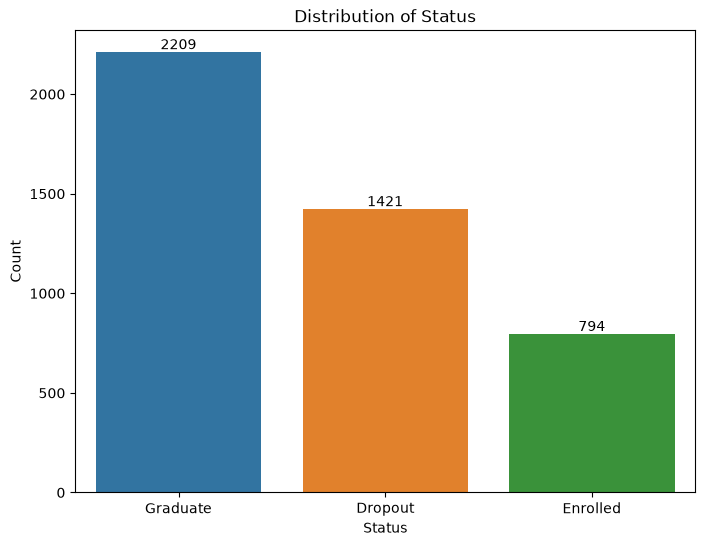

In [23]:
status_counts = df['Status'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=status_counts.index, y=status_counts.values, hue=status_counts.index)
plt.title('Distribution of Status')
plt.xlabel('Status')
plt.ylabel('Count')

for i, v in enumerate(status_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()

**Insight:** Dari total 4.424 mahasiswa, distribusi status mahasiswa adalah:
- Graduate: 2.209 mahasiswa (~50%)
- Dropout: 1.421 mahasiswa (~32%)
- Enrolled: 794 mahasiswa (~18%, masih berstatus aktif kuliah)

Angka dropout sebesar 32% ini cukup tinggi dan menjadi dasar urgensi proyek ini bagi Jaya Jaya Institut.

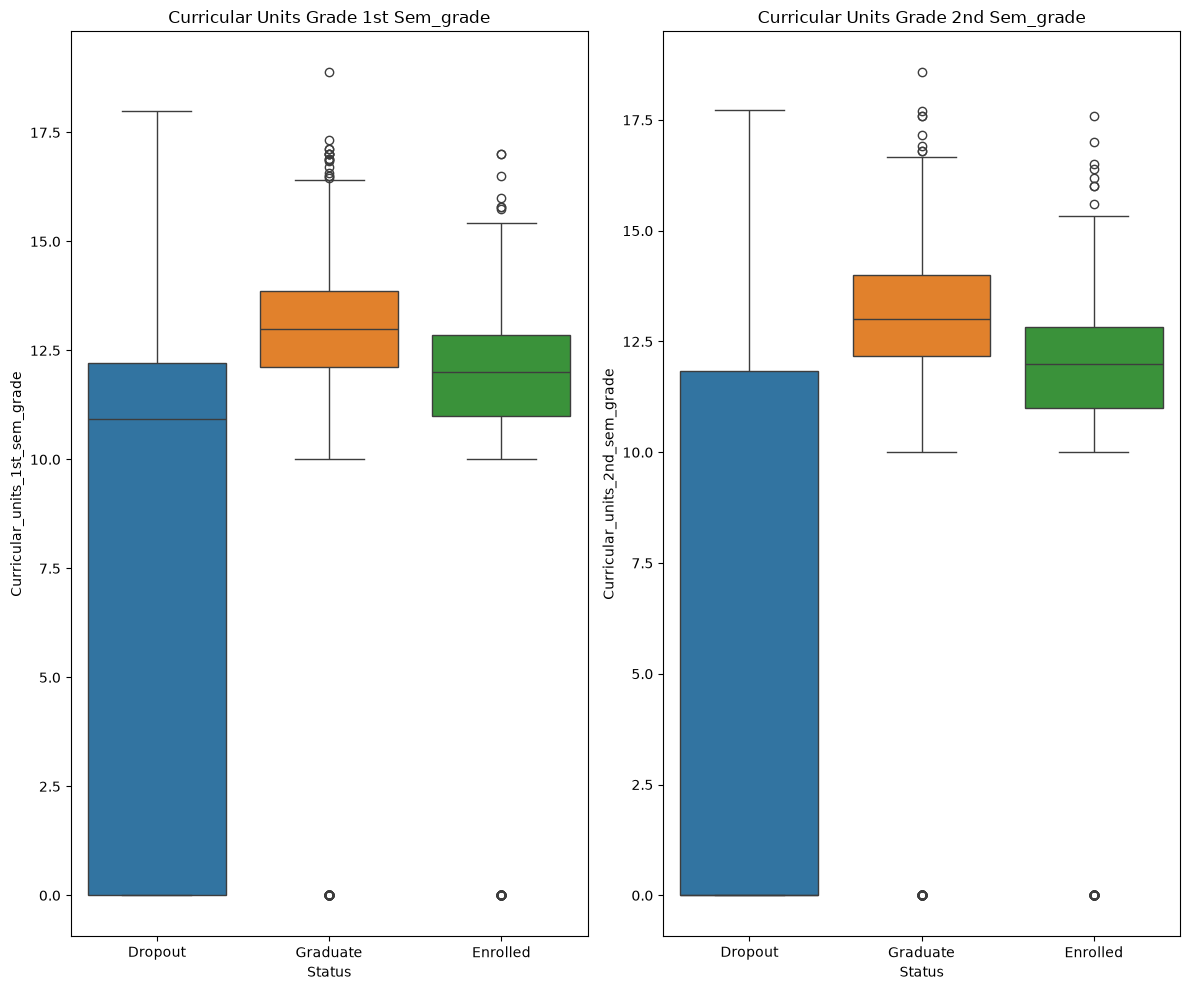

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

sns.boxplot(x='Status', y='Curricular_units_1st_sem_grade', data=df, ax=axes[0], hue='Status')
axes[0].set_title('Curricular Units Grade 1st Sem_grade')

sns.boxplot(x='Status', y='Curricular_units_2nd_sem_grade', data=df, ax=axes[1], hue='Status')
axes[1].set_title('Curricular Units Grade 2nd Sem_grade')

plt.tight_layout()
plt.show()

**Insight:** Mahasiswa berstatus Dropout cenderung memiliki nilai (grade) semester 1 dan semester 2 yang jauh lebih rendah dibandingkan mahasiswa Enrolled maupun Graduate. Ini mengindikasikan bahwa performa akademik di semester-semester awal merupakan sinyal penting untuk mendeteksi risiko dropout sejak dini.

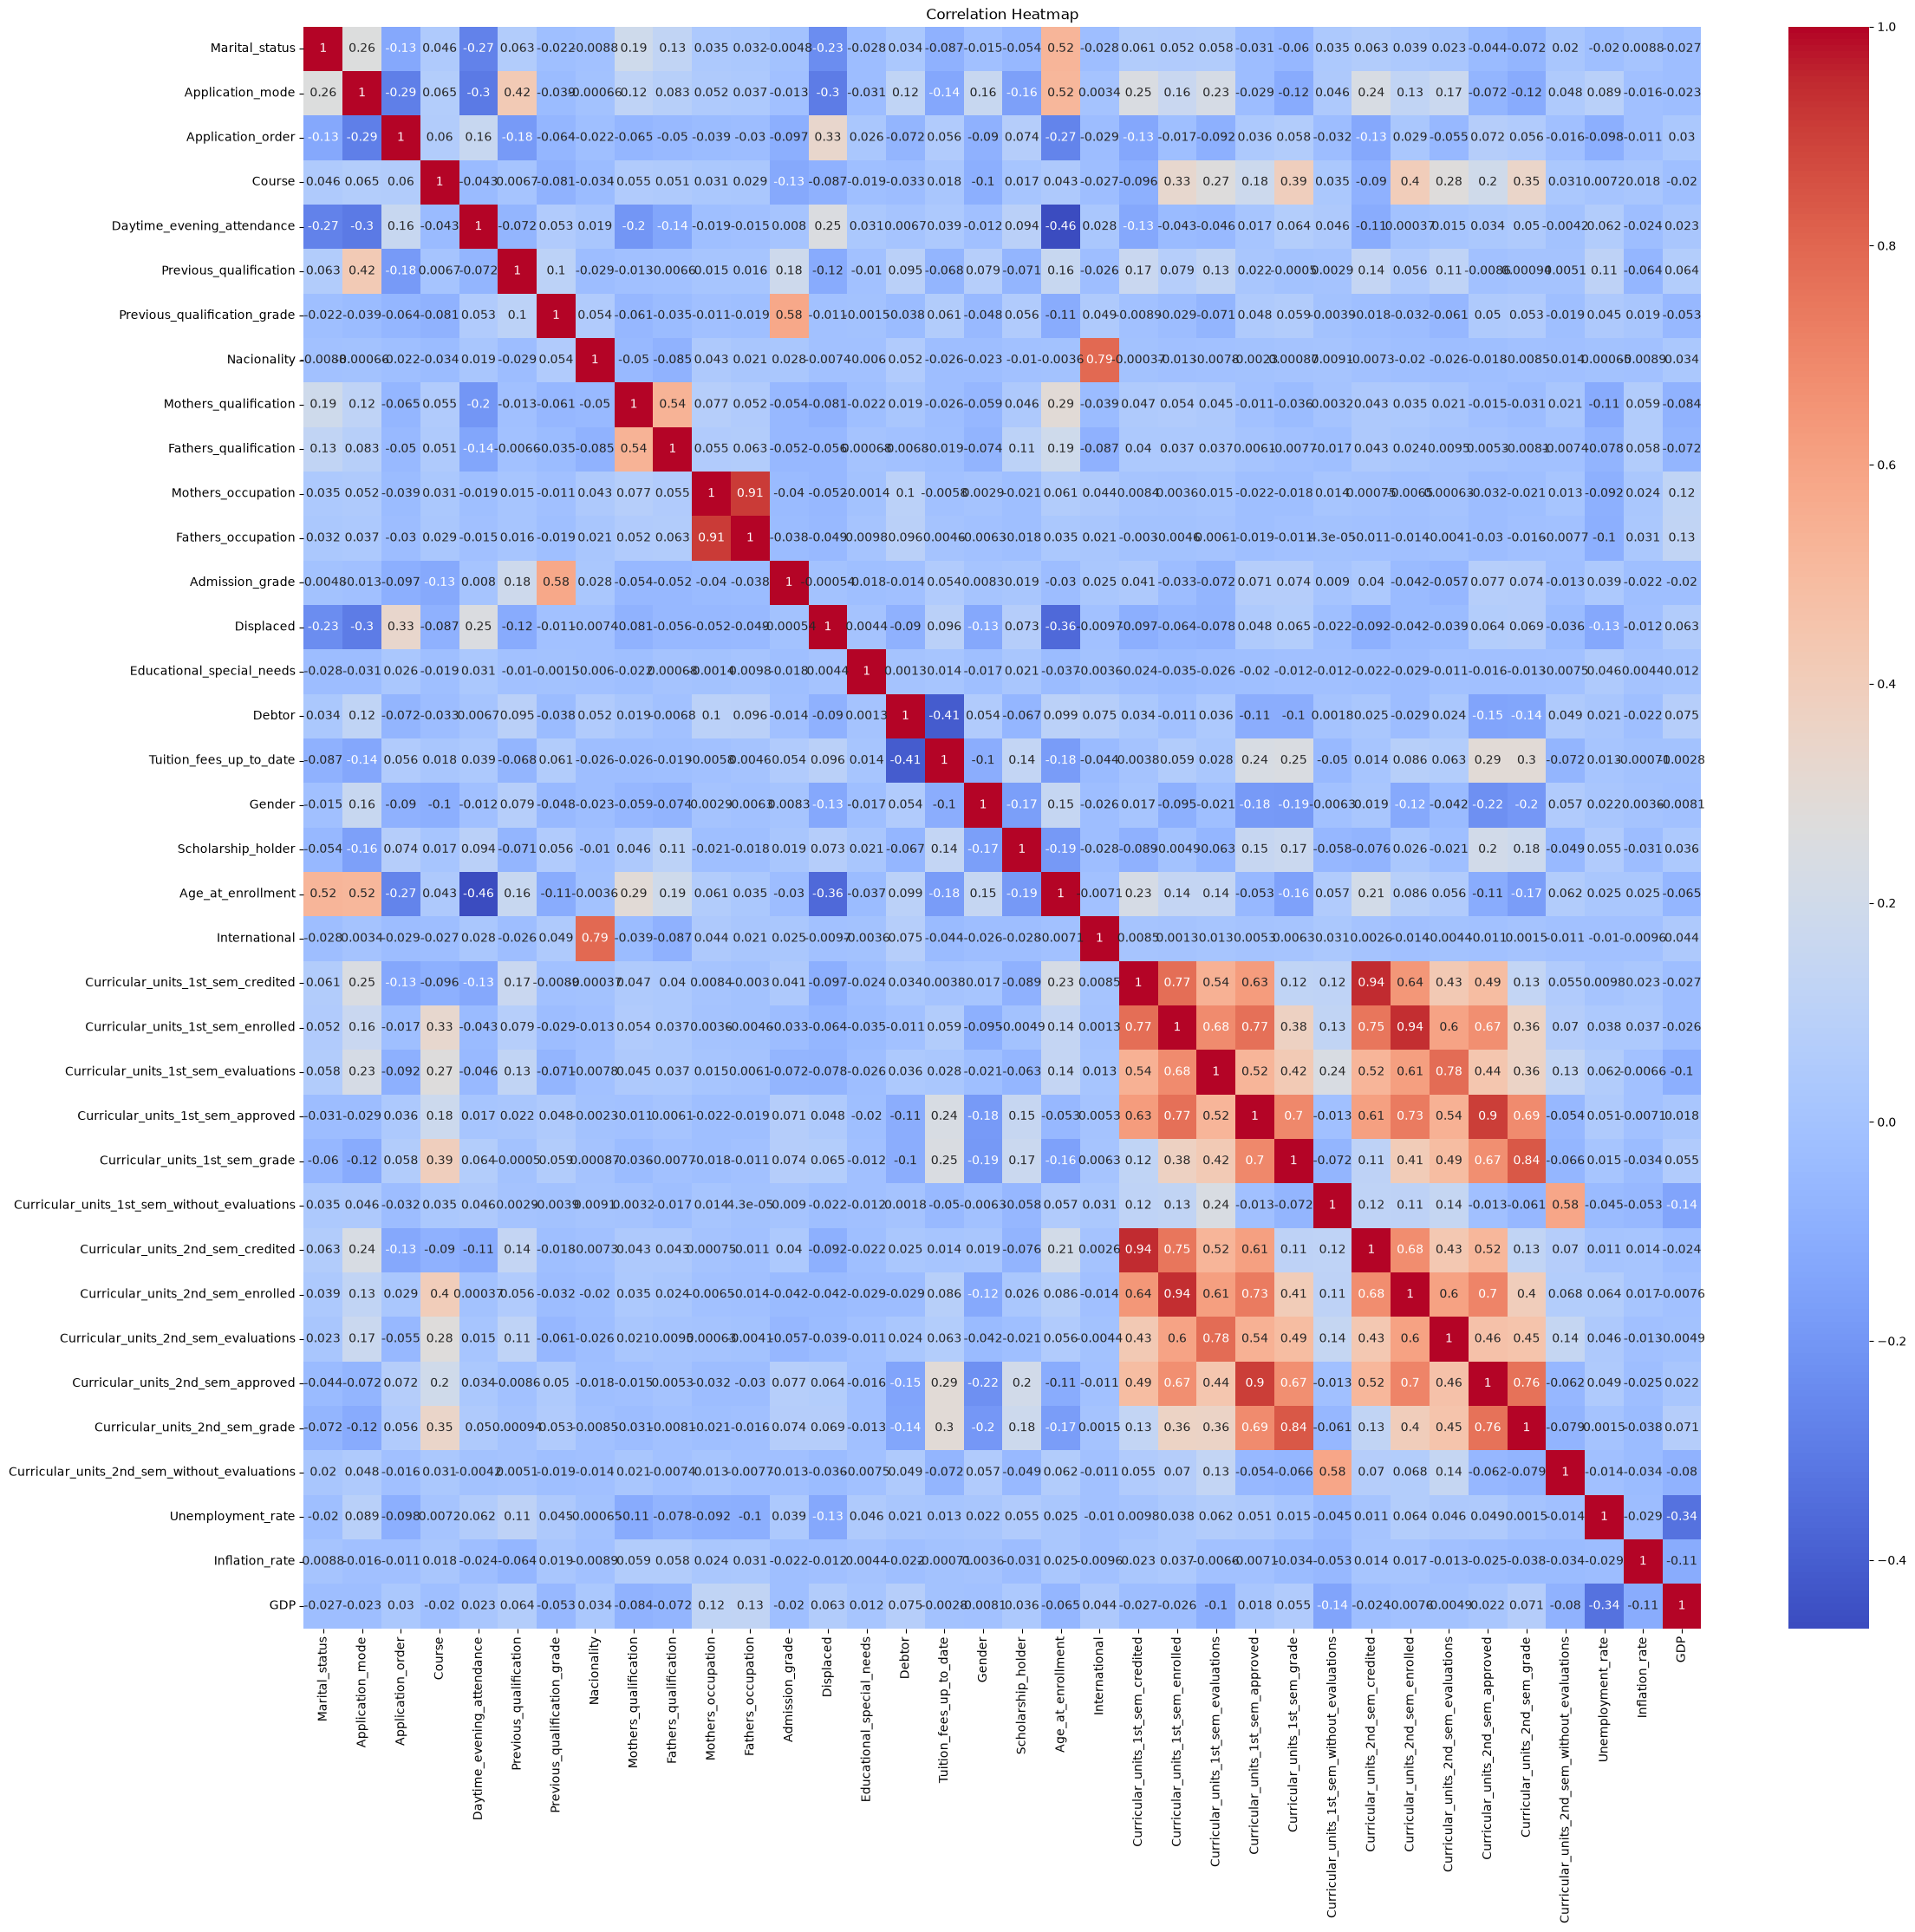

In [25]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(26, 24))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Insight:** Heatmap korelasi menunjukkan bahwa fitur-fitur yang berasal dari kelompok Curricular Units (jumlah mata kuliah yang diambil, dievaluasi, dan disetujui/lulus pada semester 1 & 2) saling berkorelasi cukup kuat satu sama lain, yang wajar karena berasal dari proses akademik yang sama. Beberapa fitur sosio-ekonomi seperti Mothers_qualification dan Fathers_qualification juga menunjukkan korelasi antar sesama fitur keluarga.

C:\Users\acer\AppData\Local\Temp\ipykernel_10016\3903926376.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target, y=corr_target.index, palette='coolwarm')


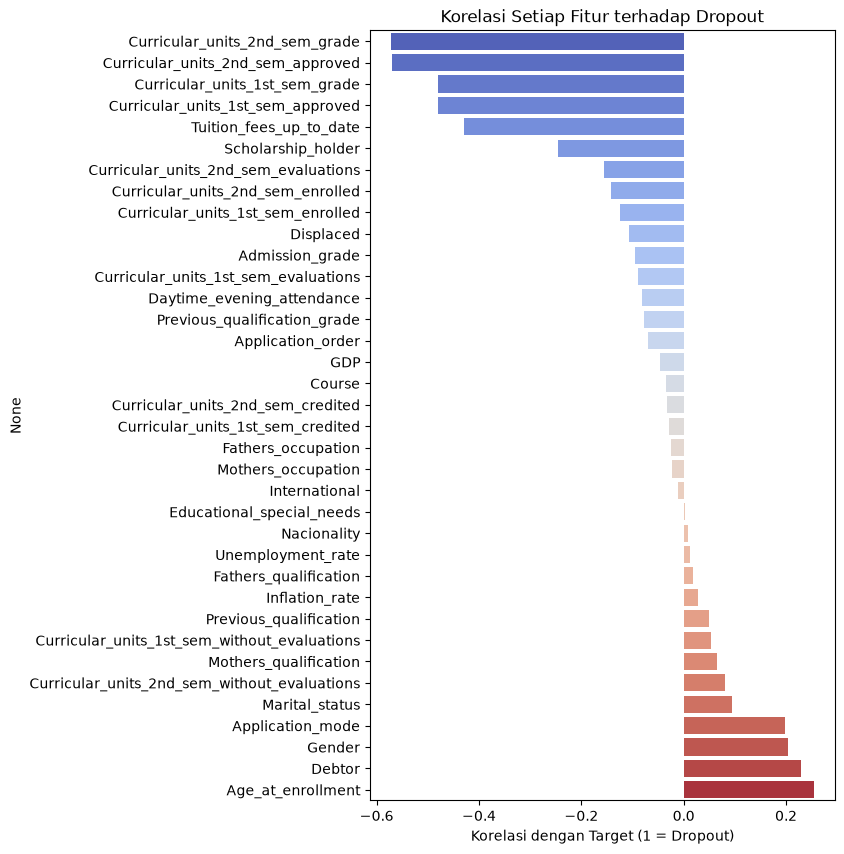

In [26]:
corr_target = df.assign(Target=df['Status'] == 'Dropout').corr(numeric_only=True)['Target'].drop('Target').sort_values()

plt.figure(figsize=(6, 10))
sns.barplot(x=corr_target, y=corr_target.index, palette='coolwarm')
plt.title('Korelasi Setiap Fitur terhadap Dropout')
plt.xlabel('Korelasi dengan Target (1 = Dropout)')
plt.show()

**Insight:** Fitur dengan korelasi negatif paling kuat terhadap dropout (semakin tinggi nilainya, semakin kecil kemungkinan dropout) adalah jumlah mata kuliah yang disetujui/lulus (approved) pada semester 1 dan 2, serta status pembayaran UKT (Tuition_fees_up_to_date). Sebaliknya, fitur seperti Debtor (status memiliki tunggakan) menunjukkan korelasi positif terhadap dropout. Temuan ini konsisten dengan hasil EDA sebelumnya dan akan sangat berguna sebagai prediktor utama pada model machine learning.

## Data Preparation / Preprocessing

Catatan: Tujuan utama sistem ini adalah memprediksi apakah seorang mahasiswa akan Dropout atau Graduate. Mahasiswa berstatus Enrolled merupakan mahasiswa yang masih aktif kuliah dan belum memiliki label/hasil akhir, sehingga:

- Data Enrolled tidak digunakan dalam proses training model, karena akan membuat target menjadi tidak jelas (bukan hasil akhir yang pasti).
- Data Enrolled akan dipisahkan dan justru digunakan sebagai data prediksi di masa mendatang — artinya model yang sudah dilatih pada mahasiswa Dropout & Graduate nantinya dipakai untuk memprediksi risiko dropout mahasiswa yang saat ini masih Enrolled.

Tahapan yang dilakukan pada bagian ini:
1. Filtering data menjadi dua bagian: data untuk training (Status = Dropout/Graduate) dan data Enrolled (disimpan terpisah).
2. Membuat target biner: 1 = Dropout, 0 = Graduate.
3. Memisahkan fitur (X) dan target (y), lalu membagi menjadi data training (80%) dan testing (20%), menggunakan stratify=y agar proporsi kelas Dropout/Graduate tetap seimbang di kedua bagian.
4. Melakukan Standard Scaling pada seluruh fitur numerik.

In [27]:
df_model = df[df['Status'] != 'Enrolled'].copy()
df_future = df[df['Status'] == 'Enrolled'].copy()

print('Jumlah data untuk training (Dropout & Graduate):', df_model.shape[0])
print('Jumlah data Enrolled                           :', df_future.shape[0])
print('\nDistribusi Status pada data training:')
print(df_model['Status'].value_counts())

Jumlah data untuk training (Dropout & Graduate): 3630
Jumlah data Enrolled                           : 794

Distribusi Status pada data training:
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64


**Insight:** Setelah mahasiswa Enrolled dikeluarkan, tersisa **3.630 data** untuk training, terdiri dari **2.209 mahasiswa Graduate** dan **1.421 mahasiswa Dropout**. Sebanyak **794 mahasiswa Enrolled** disimpan terpisah untuk digunakan sebagai data prediksi pada tahap selanjutnya (setelah model selesai dilatih).

In [28]:
df_future.to_csv('data/data_enrolled.csv', index=False)

df_model['Target'] = df_model['Status'].apply(lambda x: 1 if x == 'Dropout' else 0)
df_model[['Status', 'Target']].head()

,Status,Target
0,Dropout,1
1,Graduate,0
2,Dropout,1
3,Graduate,0
4,Graduate,0


**Catatan:** Target biner yang dibentuk adalah:
- 1 = Dropout
- 0 = Graduate

Urutan ini penting untuk diperhatikan saat membaca hasil evaluasi model (classification report & confusion matrix) pada tahap berikutnya.

In [29]:
x = df_model.drop(columns=['Status', 'Target'])
y = df_model['Target']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print('Ukuran data training :', X_train.shape)
print('Ukuran data testing  :', X_test.shape)

Ukuran data training : (2904, 36)
Ukuran data testing  : (726, 36)


**Insight:** Data berhasil dibagi menjadi **2.904 data latih (training)** dan **726 data uji (testing)**, dengan proporsi 80:20. Penggunaan stratify=y memastikan proporsi mahasiswa Dropout dan Graduate tetap seimbang di kedua bagian data.

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

df_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
df_scaled.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
0,-0.299915,1.183471,-0.564098,0.132903,0.35928,-0.342066,0.537140,-0.126097,1.087255,-1.275765,...,-0.189776,-0.28645,-0.575803,-1.954321,-1.446403,-1.848152,-0.198539,1.440766,1.116580,-1.773740
1,-0.299915,-0.999463,2.421126,0.185848,0.35928,-0.342066,-0.970016,-0.126097,-1.090828,-0.231914,...,-0.189776,-0.28645,-0.132267,-1.954321,-1.446403,-1.848152,-0.198539,-1.033944,0.112406,1.563444
2,-0.299915,-0.022887,-0.564098,0.124491,0.35928,-0.342066,0.989287,-0.126097,-1.090828,-1.275765,...,-0.189776,-0.28645,-0.132267,1.319095,-0.492500,0.475814,-0.198539,0.840837,-1.106947,0.364350
3,-0.299915,1.183471,0.182208,0.335283,0.35928,-0.342066,-0.216438,-0.126097,-0.065848,-0.231914,...,-0.189776,-0.28645,0.311270,-0.191712,-1.446403,-1.848152,-0.198539,1.440766,1.116580,-1.773740
4,-0.299915,1.872818,-0.564098,0.185848,0.35928,-0.342066,-0.970016,-0.126097,1.151316,1.007658,...,-0.189776,-0.28645,-0.132267,0.060089,0.143436,0.463583,-0.198539,-1.033944,0.112406,1.563444


**Insight:** StandardScaler mengubah setiap fitur numerik agar memiliki rata-rata 0 dan standar deviasi 1. Proses ini penting terutama karena rentang nilai antar fitur sangat bervariasi, sehingga tidak ada satu fitur pun yang mendominasi proses pelatihan model hanya karena skalanya lebih besar.

## Modeling

Model yang digunakan pada proyek ini adalah **Random Forest Classifier**, yaitu model ensemble yang terdiri dari banyak decision tree. Model ini dipilih karena:
- Mampu menangani hubungan non-linear antar fitur dengan baik.
- Relatif tahan terhadap outlier dan tidak terlalu sensitif terhadap fitur yang tidak relevan.
- Menyediakan feature importance, yang berguna untuk menjelaskan faktor apa saja yang paling berpengaruh terhadap prediksi (penting untuk kebutuhan bisnis Jaya Jaya Institut).

Parameter yang digunakan:
- n_estimators=200 — jumlah pohon (tree) yang dibentuk dalam forest.
- max_depth=10 — membatasi kedalaman maksimal setiap pohon untuk mencegah overfitting.
- min_samples_split=10 — jumlah minimum sampel yang dibutuhkan untuk membagi sebuah node.
- random_state=42 — agar hasil pelatihan model konsisten/reproducible setiap kali dijalankan.

In [31]:
rf_model = RandomForestClassifier(n_estimators=200,
                                  min_samples_split=10,
                                  max_depth=10,
                                  random_state=42)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

## Evaluation

Karena permasalahan ini sekarang merupakan klasifikasi bine (Dropout vs Graduate), evaluasi dilakukan menggunakan:
- Classification report: precision, recall, dan f1-score untuk masing-masing kelas, serta akurasi keseluruhan.
- Confusion matrix: untuk melihat pola kesalahan prediksi antar kelas.
- Feature importance: untuk mengidentifikasi fitur yang paling berpengaruh terhadap prediksi model.

In [32]:
accuracy_rf = classification_report(y_test, y_pred_rf, target_names=['Graduate', 'Dropout'])
print(accuracy_rf)

              precision    recall  f1-score   support

    Graduate       0.92      0.95      0.93       442
     Dropout       0.91      0.87      0.89       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.91       726
weighted avg       0.92      0.92      0.92       726



**Insight hasil evaluasi (0 = Graduate, 1 = Dropout):**

| Kelas | Precision | Recall | F1-score |
|---|---|---|---|
| Graduate (0) | 0.92 | 0.95 | 0.93 |
| Dropout (1) | 0.91 | 0.87 | 0.89 |

Model mencapai akurasi keseluruhan sebesar 92% — meningkat signifikan dibandingkan pendekatan sebelumnya yang menyertakan kelas Enrolled (76%). Dengan hanya berfokus pada dua kelas yang labelnya jelas (Dropout & Graduate), model menjadi jauh lebih andal, dengan recall 0.87 untuk kelas Dropout — artinya model mampu mendeteksi sekitar 87% dari seluruh mahasiswa yang benar-benar dropout.

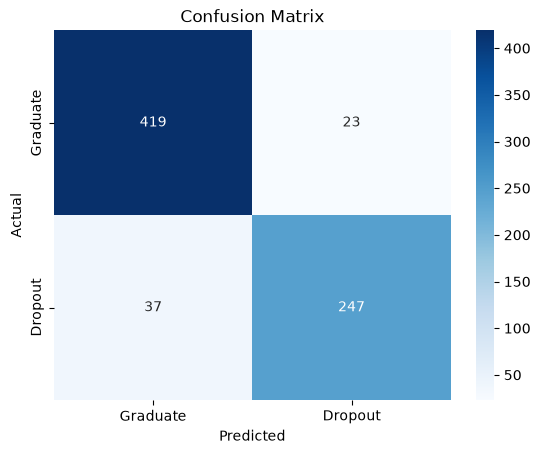

In [33]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Graduate', 'Dropout'], yticklabels=['Graduate', 'Dropout'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Insight:** Dari 726 data uji, model salah memprediksi hanya 23 mahasiswa Graduate sebagai Dropout (*false positive*) dan 37 mahasiswa Dropout sebagai Graduate (*false negative*). Tingkat kesalahan yang rendah ini menunjukkan model sudah cukup andal digunakan sebagai *early warning system* untuk mendeteksi mahasiswa berisiko dropout.

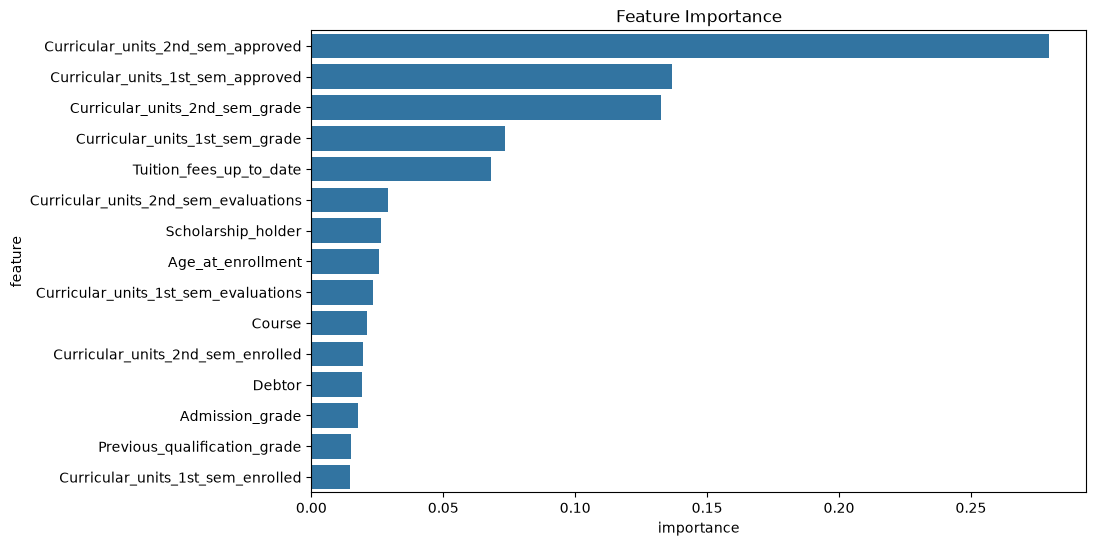

In [34]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances.head(15))
plt.title('Feature Importance')
plt.show()

**Insight:** Fitur yang paling berpengaruh terhadap prediksi Dropout vs Graduate adalah:
1. Curricular_units_2nd_sem_approved (jumlah mata kuliah lulus semester 2) — fitur paling penting.
2. Curricular_units_1st_sem_approved (jumlah mata kuliah lulus semester 1)
3. Curricular_units_2nd_sem_grade (rata-rata nilai semester 2)
4. Curricular_units_1st_sem_grade (rata-rata nilai semester 1)
5. Tuition_fees_up_to_date (status pembayaran UKT)

Temuan ini konsisten dengan hasil EDA sebelumnya: **performa akademik di semester awal** dan **kondisi finansial (UKT)** merupakan faktor paling dominan dalam menentukan apakah seorang mahasiswa akan Dropout atau Graduate.

### Karakteristik Umum Mahasiswa yang Cenderung Dropout

Selain melihat *feature importance*, penting juga untuk memahami karakteristik umum mahasiswa yang dropout dibandingkan yang graduate (dilihat dari rata-rata nilai tiap kelompok pada data training):

| Karakteristik | Dropout | Graduate |
|---|---|---|
| Usia saat mendaftar (rata-rata) | 26.1 tahun | 21.8 tahun |
| Rata-rata nilai semester 1 | 7.26 | 12.64 |
| Rata-rata nilai semester 2 | 5.90 | 12.70 |
| Rata-rata jumlah mata kuliah lulus semester 1 | 2.55 | 6.23 |
| Rata-rata jumlah mata kuliah lulus semester 2 | 1.94 | 6.18 |
| Proporsi berstatus debitur (punya tunggakan) | 22.0% | 4.6% |
| Proporsi pembayaran UKT lancar | 67.8% | 98.7% |
| Proporsi penerima beasiswa | 9.4% | 38.0% |
| Proporsi laki-laki (Gender=1) | 49.3% | 24.8% |

Kesimpulannya, mahasiswa yang cenderung dropout memiliki profil sebagai berikut:
- Mendaftar di usia yang lebih tua (rata-rata 26 tahun, dibanding 22 tahun pada mahasiswa yang graduate).
- Performa akademik jauh lebih rendah sejak semester 1 — nilai rata-rata hanya sekitar 7 (skala 0-20) dan hanya lulus 2-3 mata kuliah, dibandingkan mahasiswa graduate yang rata-rata lulus 6 mata kuliah dengan nilai sekitar 12-13.
- Kondisi finansial lebih rentan — proporsi yang berstatus debitur 5x lebih tinggi, dan yang menunggak UKT jauh lebih banyak.
- Jarang menerima beasiswa — hanya sekitar 1 dari 10 mahasiswa dropout yang menerima beasiswa, dibanding hampir 4 dari 10 pada mahasiswa graduate.
- Proporsi laki-laki lebih tinggi pada kelompok dropout dibanding kelompok graduate.

In [35]:
joblib.dump(rf_model, 'model/rf_model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')

print('Model dan scaler berhasil disimpan.')

Model dan scaler berhasil disimpan.


### Prediksi pada Mahasiswa Berstatus Enrolled (Data Masa Depan)

Sesuai tujuan awal, mahasiswa yang masih berstatus Enrolled (belum memiliki hasil akhir) tidak dilibatkan dalam proses training. Namun, model yang telah dilatih dapat langsung dimanfaatkan untuk memprediksi risiko dropout pada kelompok mahasiswa ini, sehingga pihak Jaya Jaya Institut bisa segera memberikan intervensi kepada mahasiswa yang terindikasi berisiko tinggi.

In [36]:
future_features = df_future.drop(columns=['Status'])
future_features_scaled = scaler.transform(future_features)

future_predictions = rf_model.predict(future_features_scaled)
future_proba = rf_model.predict_proba(future_features_scaled)[:, 1]

df_future_result = df_future.copy()
df_future_result['Predicted_Status'] = pd.Series(future_predictions, index=df_future.index).map({0: 'Graduate', 1: 'Dropout'})
df_future_result['Dropout_Probability'] = future_proba

print('Jumlah mahasiswa Enrolled yang diprediksi Dropout :', (future_predictions == 1).sum())
print('Jumlah mahasiswa Enrolled yang diprediksi Graduate:', (future_predictions == 0).sum())

df_future_result[['Status', 'Predicted_Status', 'Dropout_Probability']].head(10)

Jumlah mahasiswa Enrolled yang diprediksi Dropout : 356
Jumlah mahasiswa Enrolled yang diprediksi Graduate: 438


,Status,Predicted_Status,Dropout_Probability
16,Enrolled,Dropout,0.926291
19,Enrolled,Graduate,0.117727
21,Enrolled,Graduate,0.149459
25,Enrolled,Graduate,0.416875
27,Enrolled,Graduate,0.104300
29,Enrolled,Graduate,0.096100
30,Enrolled,Graduate,0.485859
32,Enrolled,Dropout,0.876208
45,Enrolled,Dropout,0.776465
51,Enrolled,Graduate,0.076353


**Insight:** Dari 794 mahasiswa yang masih Enrolled, model memprediksi sekitar 356 mahasiswa (44.8%) berisiko Dropout. Daftar mahasiswa ini (beserta peluang dropout-nya) dapat dijadikan dasar bagi pihak akademik untuk memberikan bimbingan/konseling secara proaktif kepada mahasiswa yang terindikasi berisiko tinggi, sebelum mereka benar-benar keluar dari perkuliahan.

## Conclusion

Berdasarkan proses data understanding, EDA, hingga modeling yang telah direvisi, dapat disimpulkan:

1. Dari total 4.424 mahasiswa, sekitar 32% (1.421 mahasiswa) berstatus Dropout, ~50% (2.209 mahasiswa) Graduate, dan ~18% (794 mahasiswa) masih Enrolled — angka dropout ini cukup signifikan dan menegaskan urgensi masalah bagi Jaya Jaya Institut.
2. Mahasiswa yang cenderung dropout umumnya memiliki karakteristik: mendaftar di usia lebih tua (rata-rata 26 tahun), performa akademik yang jauh lebih rendah sejak semester 1 (nilai & jumlah mata kuliah lulus jauh di bawah mahasiswa graduate), kondisi finansial yang lebih rentan (proporsi debitur & tunggakan UKT lebih tinggi), jarang menerima beasiswa, dan proporsi yang lebih tinggi dibanding mahasiswa yang graduate.
3. Performa akademik di semester 1 dan 2 (jumlah mata kuliah yang lulus/approved dan rata-rata nilai) merupakan faktor paling berpengaruh terhadap risiko dropout, diikuti oleh status pembayaran UKT.
4. Dengan memfokuskan model hanya pada mahasiswa berstatus Dropout & Graduate (mengeluarkan mahasiswa Enrolled dari proses training karena belum memiliki label akhir), model Random Forest Classifier berhasil mencapai akurasi 92%, dengan recall 87% untuk mendeteksi mahasiswa Dropout — jauh lebih baik dibandingkan pendekatan sebelumnya yang menyertakan ketiga kelas sekaligus.
5. Model ini kemudian digunakan untuk memprediksi risiko dropout pada 794 mahasiswa yang masih Enrolled, dan hasilnya menunjukkan sekitar 356 mahasiswa (44.8%) berisiko dropout — kelompok inilah yang perlu menjadi prioritas intervensi oleh pihak akademik.
6. Model ini telah disimpan (rf_model.pkl beserta scaler.pkl) dan diimplementasikan dalam bentuk prototype aplikasi Streamlit, sehingga pihak Jaya Jaya Institut dapat langsung memanfaatkannya sebagai *early warning system*.

Rekomendasi *action items* yang lebih detail dapat dilihat pada berkas README.md.